### ***Question b)***

**Computing the stationary distribution and finding the long-run average replacement costs**

In [1]:
import numpy as np

# Initialize parameters
initial_failure_prob = 0.1  # Total number of states
failure_prob_increment = 0.01  # Increment of failure probability per time unit
state_count = int((1 - initial_failure_prob) / failure_prob_increment) # i.e., 91.
replacement_cost = 1  # Cost of replacement when failure occurs

# Initialize the transition probability matrix and Poisson matrix
transition_prob_matrix = np.zeros((state_count, state_count))
poisson_matrix = np.zeros((state_count, state_count))

# Calculate the transition probabilities and setup the Poisson matrix
for state in range(state_count):
    failure_prob = state * failure_prob_increment + 0.1
    transition_prob_matrix[state, 0] = failure_prob
    if state < state_count - 1:
        transition_prob_matrix[state, state + 1] = 1 - failure_prob

# Adjust the Poisson matrix for solving the stationary distribution
for i in range(state_count):
    for j in range(state_count):
        poisson_matrix[i, j] = -transition_prob_matrix[i, j]
    poisson_matrix[i, i] += 1
    poisson_matrix[i, -1] = replacement_cost

# Solve for the stationary distribution
stationary_distribution = np.linalg.solve(poisson_matrix.T, np.append(np.zeros(state_count - 1), 1))

# Calculate the expected replacement costs
expected_costs = stationary_distribution[:-1] @ transition_prob_matrix[:-1, 0]

print("Transition Probability Matrix:\n", transition_prob_matrix)
print("Stationary Distribution:\n", stationary_distribution)
print("Expected Long-run Replacement Costs:", expected_costs)

Transition Probability Matrix:
 [[0.1  0.9  0.   ... 0.   0.   0.  ]
 [0.11 0.   0.89 ... 0.   0.   0.  ]
 [0.12 0.   0.   ... 0.   0.   0.  ]
 ...
 [0.97 0.   0.   ... 0.   0.03 0.  ]
 [0.98 0.   0.   ... 0.   0.   0.02]
 [0.99 0.   0.   ... 0.   0.   0.  ]]
Stationary Distribution:
 [1.46097542e-01 1.31487788e-01 1.17024131e-01 1.02981235e-01
 8.95936746e-02 7.70505602e-02 6.54929762e-02 5.50141000e-02
 4.56617030e-02 3.74425964e-02 3.03285031e-02 2.42628025e-02
 1.91676140e-02 1.49507389e-02 1.15120690e-02 8.74917240e-03
 6.56187930e-03 4.85579068e-03 3.54472720e-03 2.55220358e-03
 1.81206454e-03 1.26844518e-03 8.75227175e-04 5.95154479e-04
 3.98753501e-04 2.63177311e-04 1.71065252e-04 1.09481761e-04
 6.89735096e-05 4.27635759e-05 2.60857813e-05 1.56514688e-05
 9.23436658e-06 5.35593262e-06 3.05288159e-06 1.70961369e-06
 9.40287531e-07 5.07755267e-07 2.69110291e-07 1.39937351e-07
 7.13680492e-08 3.56840246e-08 1.74851721e-08 8.39288259e-09
 3.94465482e-09 1.81454122e-09 8.16543547e-

### ***Question c)***

**Simulation**

In [3]:
import numpy as np

def simulate_system(state_count, failure_prob_initial, failure_prob_increment, steps):
    current_state = 0
    total_cost = 0
    for _ in range(steps):
        failure_prob = failure_prob_initial + current_state * failure_prob_increment
        if np.random.rand() < failure_prob:
            # System fails and goes back to state 0, incurring replacement cost
            current_state = 0
            total_cost += 1
        else:
            # System does not fail and transitions to the next state
            current_state = min(current_state + 1, state_count - 1)
    # Average cost is total cost divided by the number of steps
    return total_cost / steps

# Parameters for simulation
state_count = 91
failure_prob_initial = 0.1
failure_prob_increment = 0.01
steps = 10**6  # Number of steps to simulate
num_tests = 10  # Number of times the simulation is run

# Run the simulations and store the results
simulation_results = [simulate_system(state_count, failure_prob_initial, failure_prob_increment, steps) for _ in range(num_tests)]

# Calculate the average and standard deviation of the simulated average replacement costs
average_of_simulations = np.mean(simulation_results)
std_of_simulations = np.std(simulation_results)

print("Simulated Average Replacement Costs over {} tests:".format(num_tests), simulation_results)
print("Mean of Simulated Average Replacement Cost:", average_of_simulations)
print("Standard Deviation of Simulated Average Replacement Cost:", std_of_simulations)

Simulated Average Replacement Costs over 10 tests: [0.1460829, 0.14608045, 0.14607717, 0.14605028, 0.14609896, 0.14604375, 0.14610237, 0.14614637, 0.1460784, 0.14610757]
Mean of Simulated Average Replacement Cost: 0.146086822
Standard Deviation of Simulated Average Replacement Cost: 2.7885669724787622e-05


#### Stationary distribution plot

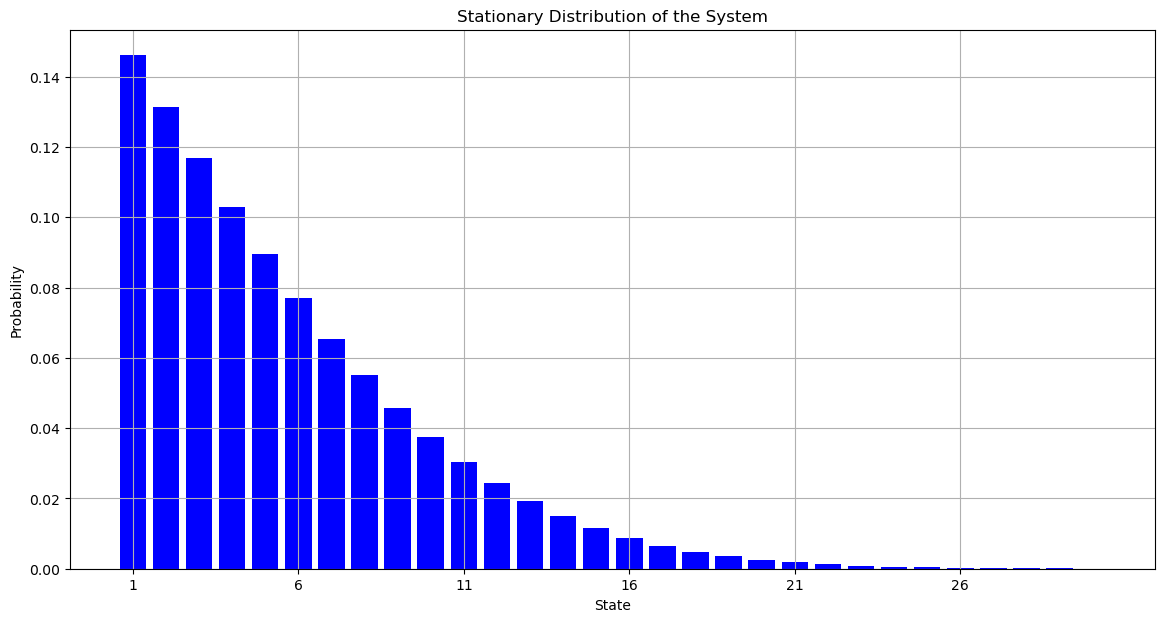

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
right_limit = 30  # Limit to the first 30 states
states = np.arange(1, right_limit + 1)  # Start state numbering from 1

plt.bar(states, stationary_distribution[:right_limit], color='blue')
plt.title('Stationary Distribution of the System')
plt.xlabel('State')
plt.ylabel('Probability')
plt.grid(True)
plt.xticks(states[::5])  # Show a label on the x-axis every 5 states, starting from 1
plt.show()

### ***Question d)***
**Solving the average-cost Poisson equations**

In [5]:
import numpy as np
from scipy.linalg import solve

# Initialize the reward vector and flag vector
# Reward for each state based on state number
rewards = [0] * 92  
# A flag vector with a '1' appended to identify the last state (used for normalization)
flags = [0] * 90  
flags.append(1)

# Initialize the transition probability matrix and Poisson matrix
# The Poisson matrix is used to solve the average-cost Poisson equation
transition_probs = np.zeros((92, 92))
poisson_matrix = np.zeros((92, 92))

# Populate the rewards vector with the linearly increasing failure cost for states 0 to 90
for state in range(91):
    rewards[state] = state * 0.01 + 0.1

# Build the Poisson matrix based on transition probabilities and failure costs
for state in range(91):
    poisson_matrix[state, state] = 1  # Probability of staying in the same state
    poisson_matrix[state, min(state + 1, 91)] = state * 0.01 - 0.9  # Probability of moving to the next state
    poisson_matrix[state, 0] -= state * 0.01 + 0.1  # Adjusted probability of failure
    poisson_matrix[state, 91] = 1  # Transition to terminal state

# The terminal state transitions to itself
poisson_matrix[91, 0] = 1

# Solve the Poisson equation to find the long-run average costs
average_costs = solve(poisson_matrix, rewards)

# Output the result
print("Long-run average costs: (V(1):V(91),Phi) =", np.array2string(average_costs, formatter={'float_kind':'{0:.4f}'.format}))

Long-run average costs: (V(1):V(91),Phi) = [0.0000 0.0512 0.0981 0.1411 0.1807 0.2172 0.2510 0.2823 0.3113 0.3383
 0.3634 0.3869 0.4088 0.4294 0.4487 0.4668 0.4838 0.4999 0.5151 0.5294
 0.5430 0.5559 0.5681 0.5796 0.5906 0.6011 0.6111 0.6206 0.6297 0.6384
 0.6467 0.6546 0.6622 0.6695 0.6765 0.6832 0.6897 0.6959 0.7019 0.7076
 0.7131 0.7185 0.7236 0.7286 0.7334 0.7380 0.7425 0.7469 0.7510 0.7551
 0.7590 0.7629 0.7666 0.7701 0.7736 0.7770 0.7803 0.7835 0.7866 0.7896
 0.7925 0.7954 0.7981 0.8008 0.8035 0.8060 0.8085 0.8110 0.8133 0.8157
 0.8179 0.8201 0.8223 0.8244 0.8265 0.8285 0.8304 0.8324 0.8342 0.8361
 0.8379 0.8396 0.8413 0.8430 0.8447 0.8463 0.8479 0.8494 0.8510 0.8524
 0.8539 0.1461]


### ***Question e)***
**MRC. Finding the average optimal policy**

#### **I. Policy iteration**

In [14]:
import numpy as np
from scipy.linalg import solve
import operator

# Initialize rewards and transition probabilities matrices
rewards = np.zeros((92, 2))
trans_probs = np.zeros((92, 92, 2)) 

# Populate the rewards matrix
for state in range(91):
    rewards[state, 0] = state * 0.01 + 0.1  # action 1 == wait
    rewards[state, 1] = 0.6                # action 2 == replace
    
# Populate the transition probabilities matrix
for state in range(91):
    # For action 1
    trans_probs[state, state, 0] = 1
    trans_probs[state, min(state + 1, 91), 0] = state * 0.01 - 0.9
    trans_probs[state, 0, 0] -= state * 0.01 + 0.1
    trans_probs[state, 91, 0] = 1

    # For action 2
    trans_probs[state, state, 1] = 1
    trans_probs[state, 0, 1] -= 1
    trans_probs[state, 91, 1] = 1

# Terminal state transition probabilities
trans_probs[91, 0, 0] = 1
trans_probs[91, 0, 1] = 1

# Policy iteration initialization
current_policy = [0] * 91
policy = [0] * 91  
value_function = solve(trans_probs[:, :, 0], rewards[:, 0]) 

# Policy iteration loop
while True:
    # Iterate over all states to improve the policy
    for state in range(91):
        # Calculate value for each action
        value_action_0 = -value_function[(state + 1) % 91] * trans_probs[state, (state + 1) % 91, 0] + \
                         -value_function[0] * trans_probs[state, 0, 0] + rewards[state, 0]
        # Special case for state 0
        if state == 0:
            value_action_0 = -value_function[(state + 1) % 91] * trans_probs[state, (state + 1) % 91, 0] + \
                             0.1 * value_function[0] + rewards[state, 0]
        value_action_1 = -value_function[0] * trans_probs[state, 0, 1] + rewards[state, 1]
        
        # Choose the action with the higher value (lower negative reward)
        current_policy[state] = 0 if value_action_0 <= value_action_1 else 1

    # Check if the policy has changed from the previous iteration
    if operator.eq(policy, current_policy):
        print("Optimal Policy (0 for wait, 1 for replace):", current_policy)
        print("Value Function: (V(1):V(91),Phi)", np.array2string(value_function, formatter={'float_kind':'{0:.4f}'.format}))
        break

    # Recalculate the value function based on the new policy
    policy_matrix = np.zeros((92, 92))
    reward_vector = np.zeros(92)
    for state in range(91):
        for next_state in range(92):
            policy_matrix[state, next_state] = trans_probs[state, next_state, current_policy[state]]
        reward_vector[state] = rewards[state, current_policy[state]]

    # Special case for the terminal state
    for next_state in range(92):
        policy_matrix[91, next_state] = trans_probs[91, next_state, 0]
    reward_vector[91] = rewards[91, 0]

    # Update value function
    value_function = solve(policy_matrix, reward_vector)
    policy = current_policy

Optimal Policy (0 for wait, 1 for replace): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Value Function: (V(1):V(91),Phi) [-0.0000 0.0511 0.0978 0.1407 0.1801 0.2164 0.2498 0.2807 0.3093 0.3357
 0.3601 0.3826 0.4033 0.4221 0.4391 0.4540 0.4540 0.4540 0.4540 0.4540
 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540
 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540
 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540
 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540
 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540
 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540
 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540 0.4540
 0.4540 0

#### **II. Value iteration**

In [15]:
# Updated code with only the number of iterations for convergence

import numpy as np

# Initialize rewards and transition probabilities for two actions
rewards_matrix = np.zeros((91, 2))
transition_matrix = np.zeros((91, 91, 2))

# Define the rewards for waiting (0) and replacing (1) for each state
for state in range(91):
    rewards_matrix[state, 0] = state * 0.01 + 0.1  # Incremental cost for waiting
    rewards_matrix[state, 1] = 0.6                 # Fixed cost for replacing

# Define transition probabilities based on the actions taken
for state in range(91):
    # Probabilities when waiting
    transition_matrix[state, (state + 1) % 91, 0] = 0.9 - (state * 0.01) 
    transition_matrix[state, 0, 0] = (state * 0.01) + 0.1 

    # Probabilities when replacing
    transition_matrix[state, 0, 1] = 1  # Always transitions back to state 0

# Initialize value function and policy arrays
value_function = [0] * 91
policy = [0] * 91
iteration_count = 0

# Value iteration process
while True:
    iteration_count += 1
    new_value_function = np.minimum(
        rewards_matrix[:, 0] + (transition_matrix[:, :, 0] @ value_function),
        rewards_matrix[:, 1] + (transition_matrix[:, :, 1] @ value_function)
    )

    # Update policy based on the new value function
    for state in range(91):
        policy[state] = np.argmin([
            rewards_matrix[state, 0] + transition_matrix[state, :, 0] @ value_function, 
            rewards_matrix[state, 1] + transition_matrix[state, :, 1] @ value_function
        ])

    # Check for convergence
    if np.all(np.abs(new_value_function - value_function) < 0.1459):
        break

    value_function = new_value_function

# Output the results
print("Optimal Policy (0 for wait, 1 for replace):", policy)
print("Number of iterations for convergence:", iteration_count)

Optimal Policy (0 for wait, 1 for replace): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Number of iterations for convergence: 36


#### Optimal policy plot

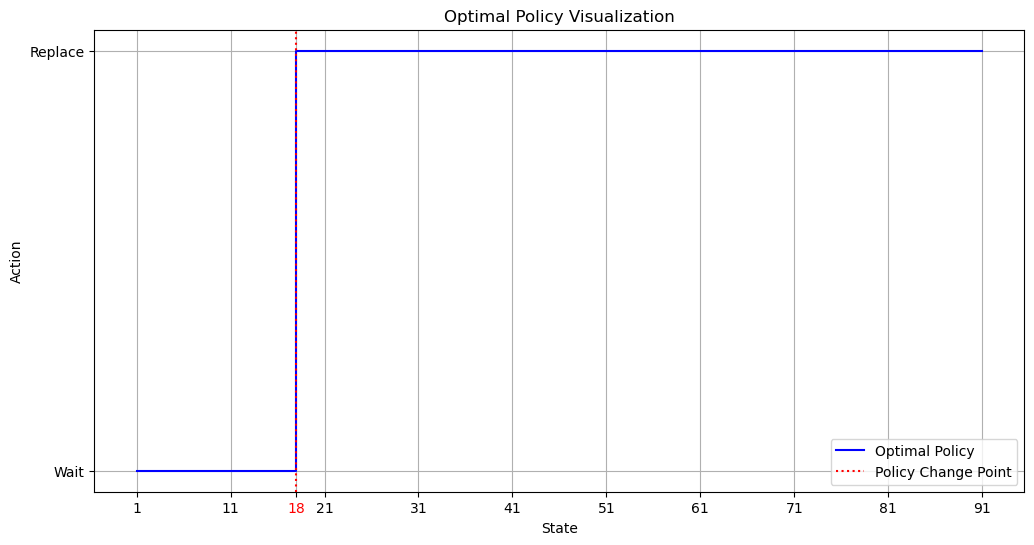

In [16]:
import matplotlib.pyplot as plt

breakpoint_state = 18 # it could be automated but hardcoded for convenience
state_labels = list(range(1, len(policy) + 2))  # State labels starting from 1

# Plotting the optimal policy with adjustments
plt.figure(figsize=(12, 6))
plt.plot(state_labels[:-1], policy, drawstyle='steps-post', color='blue', label='Optimal Policy')
plt.title('Optimal Policy Visualization')
plt.xlabel('State')
plt.ylabel('Action')

# Setting the xticks to start from state 1 and show every 10th state
xticks_labels = list(range(1, len(policy) + 2, 10))

# Include the breakpoint state in the xticks, ensuring it's in red
xticks_labels.append(breakpoint_state)
plt.xticks(xticks_labels)

# Highlight the breakpoint state tick label in red
for label in plt.gca().get_xticklabels():
    if label.get_text() == str(breakpoint_state):
        label.set_color('red')

# Draw a dotted red line at the breakpoint state
plt.axvline(x=breakpoint_state, color='red', linestyle=':', label='Policy Change Point')

plt.yticks([0, 1], ['Wait', 'Replace'])
plt.grid(True)
plt.legend()
plt.legend(loc='lower right')
plt.show()